In questo esercizio si campiona la distribuzione a posteriori di omega_m usando il metodo del rejection sampling. Si confrontano 10.000 punti generati casualmente con la soglia della posterior e si accettano solo quelli che rispettano la condizione di probabilità. Alla fine si ottiene una distribuzione campionata da cui si calcolano media e deviazione standard.

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import quad

<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_100395/580471455.py:11: SyntaxWarning: invalid escape sequence '\O'
  plt.title("Posterior Distribution of $\Omega_m$")


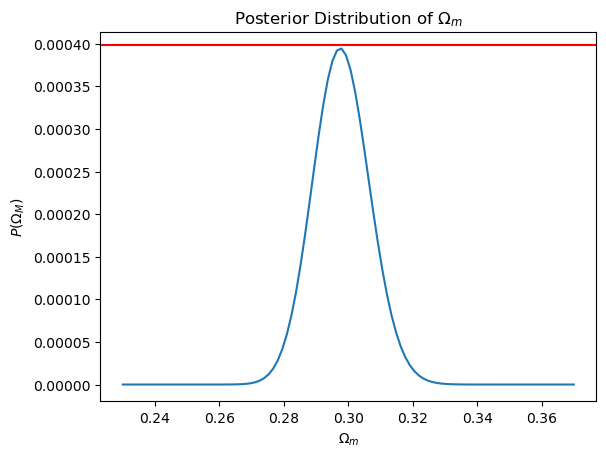

In [2]:
omega_m_values, chi2_values = np.load("chi2_values.npy")
posterior = np.exp(-0.5 * chi2_values) # Converte i chi^2 in probabilità (posterior non normalizzata)
interp_posterior = interp1d(omega_m_values, posterior, kind="cubic") # Interpolazione della distribuzione posterior

K=1.01*np.max(posterior) # Soglia K leggermente maggiore del massimo della posterior (per rejection sampling)

plt.plot(omega_m_values, posterior)
plt.axhline(K, color="red")
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$P(\Omega_M)$")
plt.title("Posterior Distribution of $\Omega_m$")
plt.show()

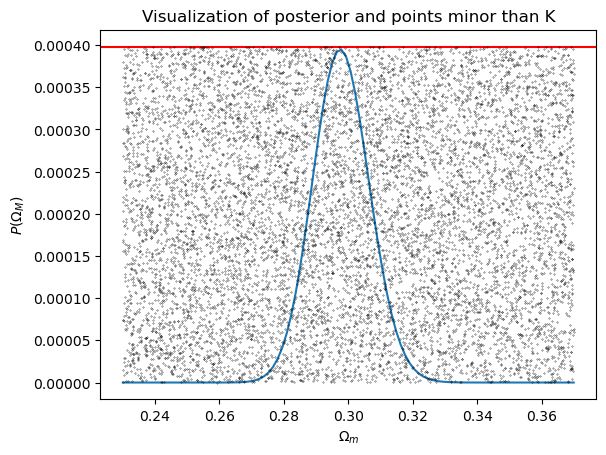

In [3]:
n_attempts = 10000
omega_m_try = np.random.uniform(0.23, 0.37, n_attempts) # Estrazione di valori di Omega_m
U=np.random.uniform(0, 1, n_attempts)  # Estrazione di valori per il rejection sampling

plt.plot(omega_m_values, posterior)
plt.axhline(K, color="red")
plt.plot(omega_m_try, U*K, ".",ms="0.5",color="k")
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$P(\Omega_M)$")
plt.title("Visualization of posterior and points minor than K")
plt.show()

[False False False ...  True False  True]


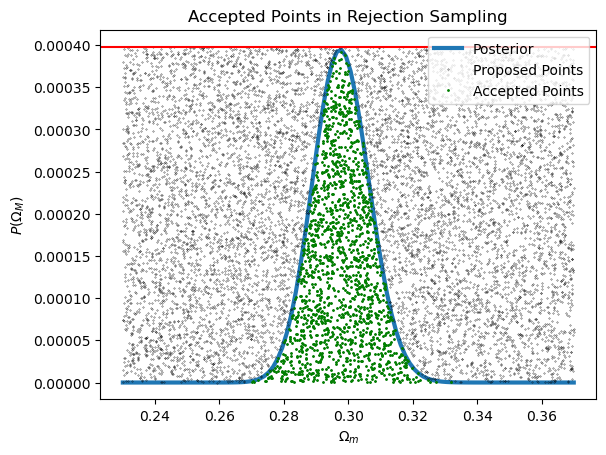

In [4]:
ff=interp_posterior(omega_m_try) #Valuta la posterior per ciascun punto proposto
acc=ff>U*K # Condizione di accettazione

print(acc)  # Mostra la maschera booleana (lista di True/False)

plt.plot(omega_m_values, posterior,lw=3) 
plt.plot(omega_m_try, U*K, ".", ms="0.5", color="k")  # Punti proposti
plt.plot(omega_m_try[acc], U[acc]*K, ".", ms="2", color="g")  # Punti accettati
plt.axhline(K, color="red")
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$P(\Omega_M)$")
plt.title("Accepted Points in Rejection Sampling")
plt.legend(["Posterior", "Proposed Points", "Accepted Points"], loc="upper right")
plt.show()

In [5]:
print("Omega_m : {mean:2.4f}+-{std:2.4f}".format(mean=np.mean(omega_m_try[acc]), std=np.std(omega_m_try[acc])))

Omega_m : 0.2977+-0.0089
